In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("GlobalYouTubeStatistics.csv", encoding="latin1", low_memory=False)

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)
df.head()

Dataset shape: (1006, 29)

Columns:
 Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country of origin', 'Country', 'Abbreviation',
       'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,NaN,2006.0,NaN,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [4]:
# Clean missing values
df.replace("nan", np.nan, inplace=True)
df.dropna(subset=["Youtuber", "subscribers"], inplace=True)

# Convert numeric columns
num_cols = ["subscribers","video views","uploads","lowest_yearly_earnings",
            "highest_yearly_earnings","subscribers_for_last_30_days",
            "video_views_for_the_last_30_days","Population",
            "Unemployment rate","Urban_population",
            "Gross tertiary education enrollment (%)","Latitude","Longitude"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [5]:
print("Top 5 YouTubers by Subscribers:")
print(df.nlargest(5, "subscribers")[["Youtuber", "subscribers", "Country"]])

print("\nAverage Subscribers by Country:")
print(df.groupby("Country")["subscribers"].mean().sort_values(ascending=False).head(10))

Top 5 YouTubers by Subscribers:
                     Youtuber  subscribers        Country
0                    T-Series  245000000.0          india
1              YouTube Movies  170000000.0  United States
2                     MrBeast  166000000.0  United States
3  Cocomelon - Nursery Rhymes  162000000.0  United States
4                   SET India  159000000.0          India

Average Subscribers by Country:
Country
india          2.450000e+08
Cuba           4.630000e+07
El Salvador    4.610000e+07
Barbados       4.190000e+07
Japan          3.782000e+07
Venezuela      3.120000e+07
Kuwait         3.050000e+07
Chile          2.906667e+07
South Korea    2.833529e+07
Pakistan       2.590000e+07
Name: subscribers, dtype: float64


In [6]:
#Top 10 YouTubers by Subscribers
df.nlargest(10, "subscribers")[["Youtuber","subscribers","Country"]]

,Youtuber,subscribers,Country
0,T-Series,245000000.0,india
1,YouTube Movies,170000000.0,United States
2,MrBeast,166000000.0,United States
3,Cocomelon - Nursery Rhymes,162000000.0,United States
4,SET India,159000000.0,India
5,Music,119000000.0,NaN
6,ýýý Kids Diana Show,112000000.0,United States
7,PewDiePie,111000000.0,Japan
8,Like Nastya,106000000.0,Russia
9,Vlad and Niki,98900000.0,United States


In [7]:
#Category with Highest Average Subscribers
df.groupby("category")["subscribers"].mean().sort_values(ascending=False).head(1)

,subscribers
category,
Shows,4.161538e+07


In [8]:
#Average Uploads per Category
df.groupby("category")["uploads"].mean().sort_values(ascending=False)

,uploads
category,
News & Politics,112484.384615
Nonprofits & Activism,102912.000000
Shows,27443.692308
Sports,19129.833333
Entertainment,12099.869198
People & Blogs,9256.793893
Trailers,6839.000000
Gaming,4198.744681
Pets & Animals,3562.800000


In [9]:
#Top 5 Countries by Channel Count
df["Country"].value_counts().head(5)

,count
Country,
United States,315
India,168
Brazil,62
United Kingdom,44
Mexico,33


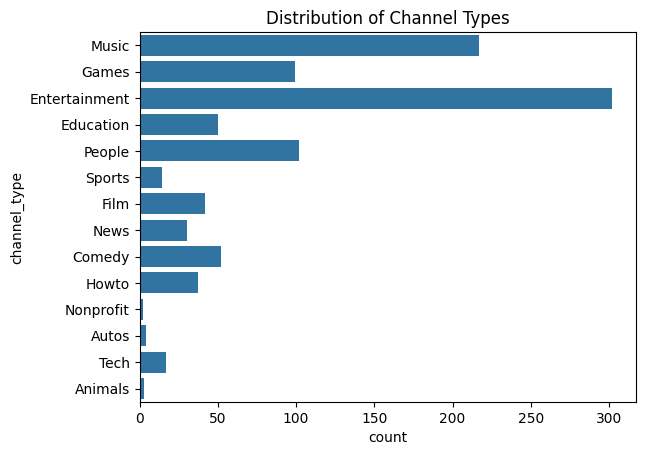

In [10]:
#Distribution of Channel Types Across Categories
sns.countplot(y="channel_type", data=df)
plt.title("Distribution of Channel Types")
plt.show()

Correlation: 0.7481786016237689


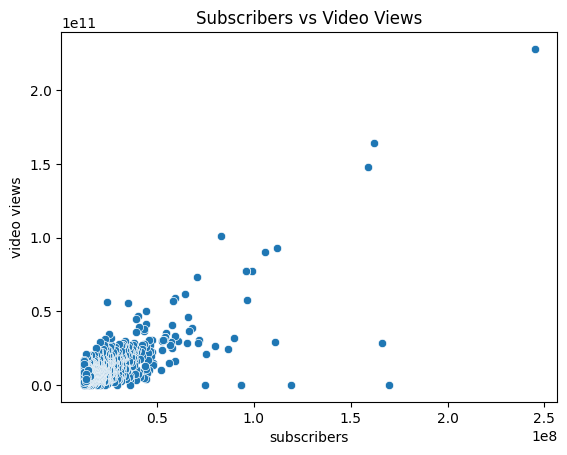

In [11]:
#Correlation Between Subscribers and Views
corr = df["subscribers"].corr(df["video views"])
print("Correlation:", corr)
sns.scatterplot(x="subscribers", y="video views", data=df)
plt.title("Subscribers vs Video Views")
plt.show()

In [12]:
#Monthly Earnings Variation by Category
earn_cols = ["lowest_monthly_earnings","highest_monthly_earnings"]
for c in earn_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df.groupby("category")[earn_cols].mean()

,lowest_monthly_earnings,highest_monthly_earnings
category,,
Autos & Vehicles,74966.666667,1.190900e+06
Comedy,41332.285714,6.597635e+05
Education,46863.239348,7.518043e+05
Entertainment,39549.816034,6.318484e+05
Film & Animation,47325.318409,7.573542e+05
Gaming,16926.064681,2.713969e+05
Howto & Style,12022.350500,1.920441e+05
Movies,28400.000000,4.547000e+05
Music,34671.696798,5.535735e+05


In [13]:
#Overall Trend in Subscribers Gained Last 30 Days
df["subscribers_for_last_30_days"].sum()

np.float64(232594874.0)

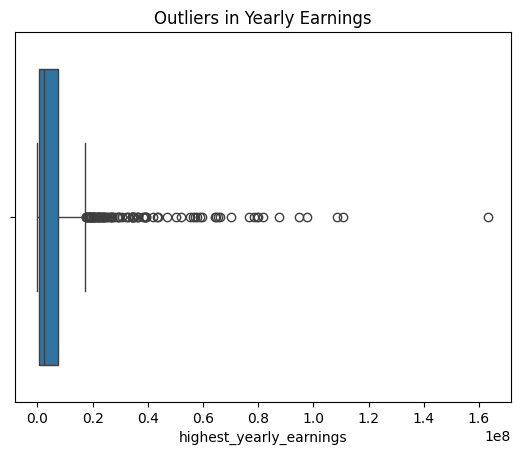

In [14]:
#Outliers in Yearly Earnings
sns.boxplot(x=df["highest_yearly_earnings"])
plt.title("Outliers in Yearly Earnings")
plt.show()

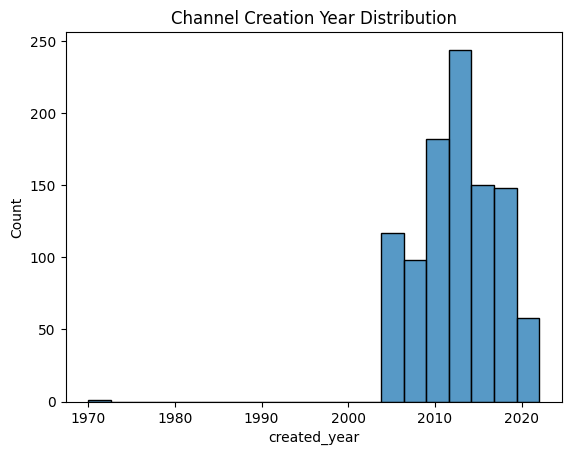

In [15]:
#Distribution of Channel Creation Dates
df["created_year"] = pd.to_numeric(df["created_year"], errors="coerce")
sns.histplot(df["created_year"], bins=20)
plt.title("Channel Creation Year Distribution")
plt.show()

In [16]:
#Education Enrollment vs Channel Count
edu_mean = df.groupby("Country")["Gross tertiary education enrollment (%)"].mean()
channel_count = df["Country"].value_counts()
edu_corr = edu_mean.corr(channel_count.reindex(edu_mean.index))
print("Correlation:", edu_corr)

Correlation: 0.11203217277509432


In [17]:
#Unemployment Rate Among Top 10 Countries
top_countries = df["Country"].value_counts().head(10).index
df[df["Country"].isin(top_countries)].groupby("Country")["Unemployment rate"].mean()

,Unemployment rate
Country,
Brazil,12.08
India,5.36
Indonesia,4.69
Mexico,3.42
Russia,4.59
South Korea,4.15
Spain,13.96
Thailand,0.75
United Kingdom,3.85


In [18]:
#Average Urban Population Percentage
df["Urban_population_percentage"] = (df["Urban_population"] / df["Population"]) * 100
avg_urban_percentage = df.groupby("Country")["Urban_population_percentage"].mean().mean()
print(avg_urban_percentage)


70.04830333449617


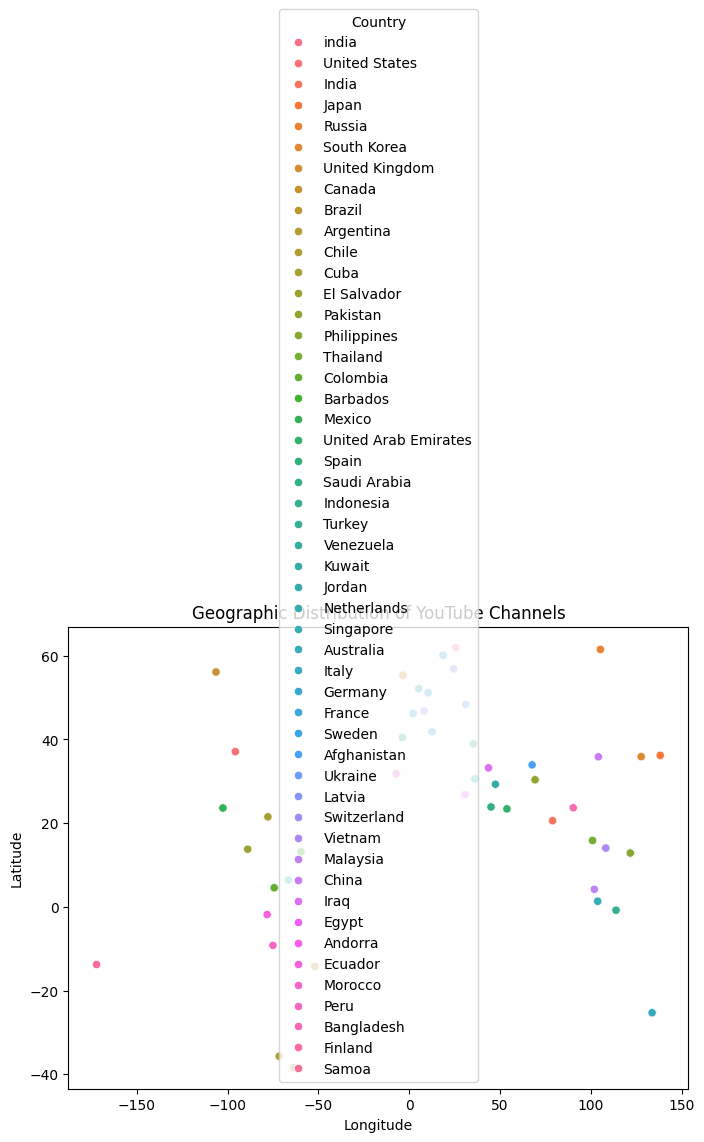

In [19]:
# Latitude–Longitude Patterns
plt.figure(figsize=(8,6))
sns.scatterplot(x="Longitude", y="Latitude", data=df, hue="Country")
plt.title("Geographic Distribution of YouTube Channels")
plt.show()

In [20]:
#Subscribers vs Population Correlation
corr_pop = df["subscribers"].corr(df["Population"])
print("Correlation:", corr_pop)

Correlation: 0.0827925967357788


In [21]:
#Top 10 Countries Comparison by Population
df[df["Country"].isin(top_countries)].groupby("Country")["Population"].mean().sort_values(ascending=False)

,Population
Country,
India,1.366418e+09
United States,3.282395e+08
Indonesia,2.702039e+08
Brazil,2.125594e+08
Russia,1.443735e+08
Mexico,1.260140e+08
Thailand,6.962558e+07
United Kingdom,6.683440e+07
South Korea,5.170910e+07


In [22]:
#Subscribers Gained vs Unemployment Rate
corr_sub_unemp = df["subscribers_for_last_30_days"].corr(df["Unemployment rate"])
print("Correlation:", corr_sub_unemp)

Correlation: -0.02185379468479244


/tmp/ipykernel_17788/2167457703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="channel_type", y="video_views_for_the_last_30_days", data=df, palette="Set3")


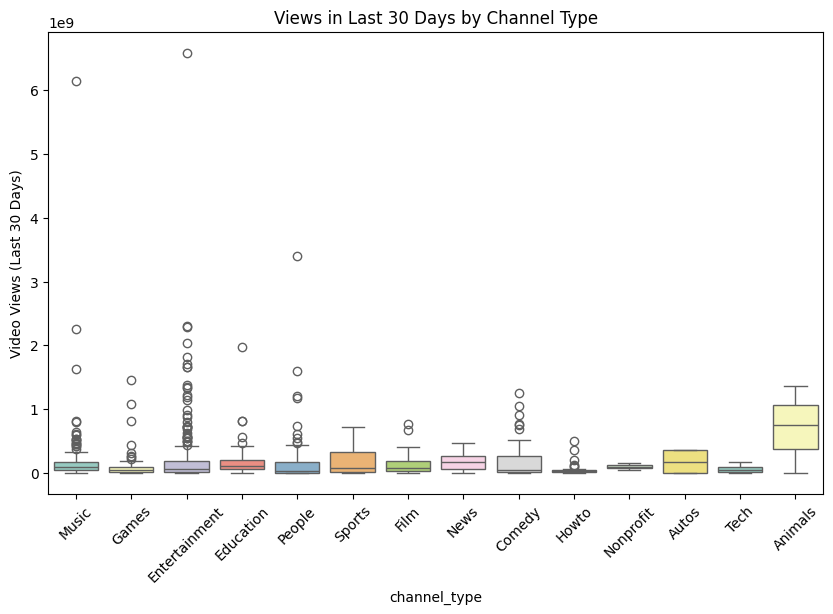

In [23]:
#Views Last 30 Days Across Channel Types
plt.figure(figsize=(10,6))
sns.boxplot(x="channel_type", y="video_views_for_the_last_30_days", data=df, palette="Set3")
plt.xticks(rotation=45)
plt.title("Views in Last 30 Days by Channel Type")
plt.ylabel("Video Views (Last 30 Days)")
plt.show()

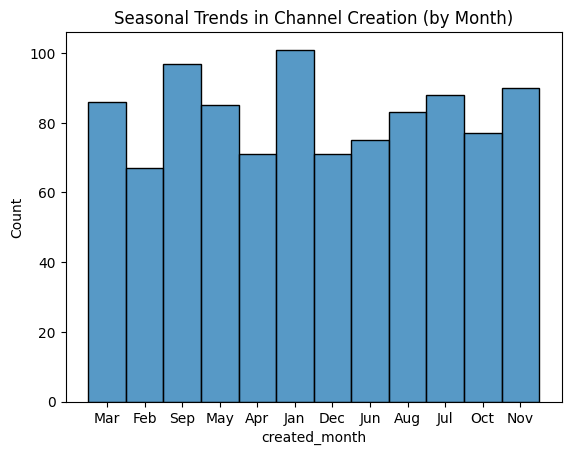

In [24]:
#Seasonal Trends in Uploads
sns.histplot(df["created_month"], bins=12)
plt.title("Seasonal Trends in Channel Creation (by Month)")
plt.show()

In [25]:
# Average Subscribers Gained Per Month Since Creation
df.loc[:, "years_since_creation"] = 2026 - df["created_year"]
df.loc[:, "avg_subs_per_month"] = df["subscribers"] / (df["years_since_creation"] * 12)
df["avg_subs_per_month"].mean()

np.float64(158511.49542487715)